144515.04108/neouter0_fp0: 5 ESCAPE loop iterations found


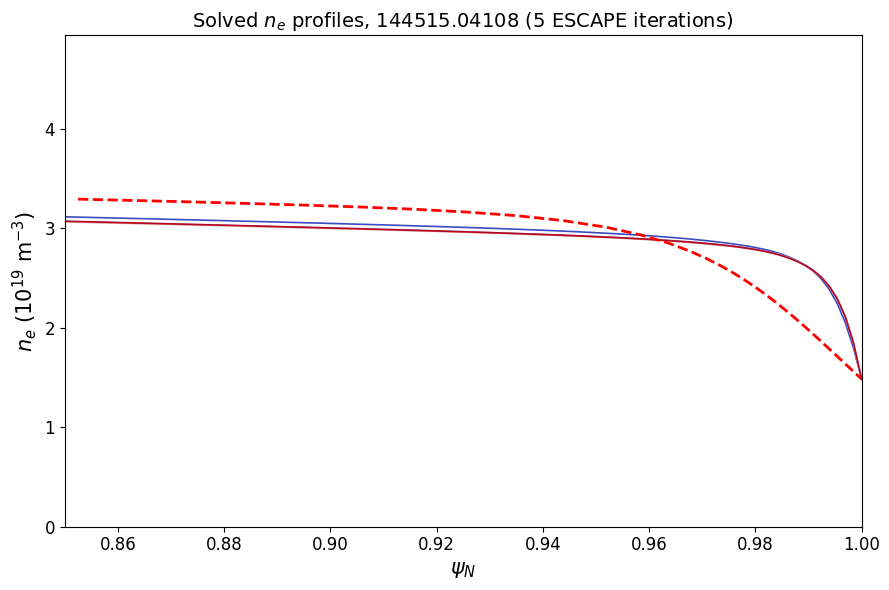

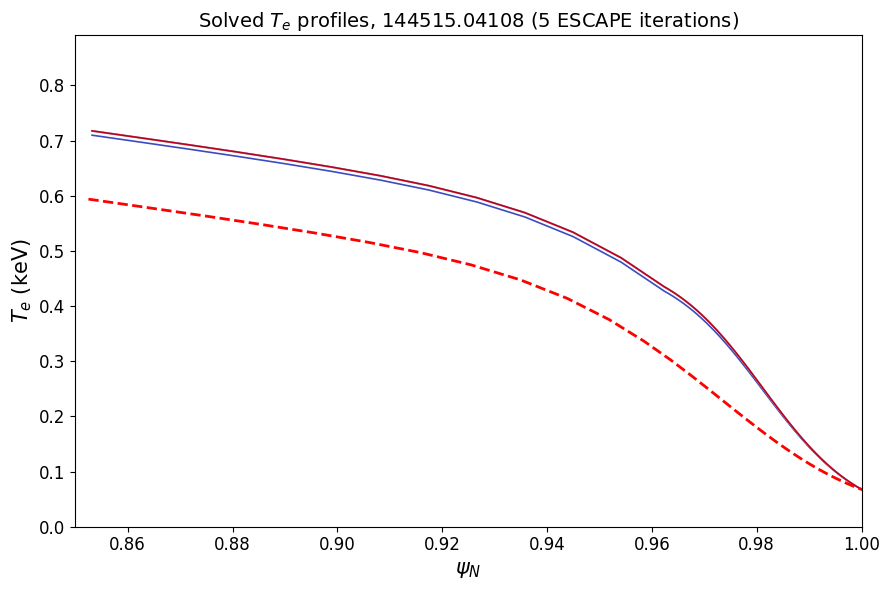

In [14]:
# --- ESCAPE loop convergence: n_e and T_e at every iteration of one debug run ---
# Reads DIIIDSnyder_freeparam_ESCAPE5000iter/{EQUIL}/{RUN}/{EQUIL}/ne_and_Te_iter_*.npy,
# the per-iteration dumps profiles_loop_solve_epednn_neped_scan.py writes on every pass
# through the ESCAPE loop (n_e = 'y' on 'psi_N_ne', the new T_e it generates for the next
# iteration = 'Te_new_keV' on 'psi_N_Te_new'). Each line is one iteration, colour-graded
# blue (early) -> red (late) by ITERATION NUMBER, so a converged run's late (red)
# iterations collapse onto the reference while a diverging one keeps drifting away -
# which is what this particular 5000-iteration run does (it never converged; see its
# failed.npy). The dashed reference curve is the experimental (OMFIT IDA) input profile
# the loop is trying to match, read directly from the IDA netCDF for this equilibrium.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import netCDF4 as nc
import numpy as np

# ------------------------------------------------------------------ user input
ITER_SCAN_DIR = Path('DIIIDSnyder_ESCAPE_nofpscan')
ITER_EQUIL = '144515.04108'       # equilibrium tag = <shot>.<time>
ITER_RUN = 'neouter0_fp0'         # free-parameter combo directory within the equilibrium
PFILE_DIR = Path('/mnt/homes_global/jal2351/software/sc_inputs/OMFITnc_HighPerfHMode')
PSI_LO_ITER = 0.85                # pedestal window for both plots
# -----------------------------------------------------------------------------


def load_escape_iters(scan_dir, equil, run):
    """All ne_and_Te_iter_*.npy dumps for one ESCAPE loop run, sorted by iteration."""
    run_dir = Path(scan_dir) / equil / run / equil
    files = sorted(run_dir.glob('ne_and_Te_iter_*.npy'),
                   key=lambda p: int(re.match(r'ne_and_Te_iter_(\d+)\.npy$', p.name).group(1)))
    return [np.load(fp, allow_pickle=True).item() for fp in files]


def reference_profiles(pfile_dir, equil):
    """Experimental (OMFIT IDA) n_e/T_e the ESCAPE loop is trying to match.

    `equil` is a <shot>.<time_ms_5digit> tag; the matching IDA netCDF is found by
    shot number and by the time window bracketing time_ms/1000 seconds.
    """
    shot, frac = equil.split('.')
    time_s = int(frac) / 1000.0
    for fp in sorted(Path(pfile_dir).glob(f'IDA_{shot}_*_*_.cdf')):
        m = re.match(rf'IDA_{shot}_([\d.]+)_([\d.]+)_\.cdf$', fp.name)
        if m and float(m.group(1)) <= time_s <= float(m.group(2)):
            break
    else:
        raise FileNotFoundError(f'no IDA netCDF for {equil} under {pfile_dir}')

    with nc.Dataset(fp) as f:
        psi = np.asarray(f.variables['psi_n'][:], dtype=float)
        ne = np.nanmean(np.ma.filled(f.variables['n_e'][:], np.nan), axis=0)
        Te_eV = np.nanmean(np.ma.filled(f.variables['T_e'][:], np.nan), axis=0)
    good = np.isfinite(psi) & np.isfinite(ne) & np.isfinite(Te_eV)
    return psi[good], ne[good], Te_eV[good] / 1e3   # Te: eV -> keV


def plot_iters(ax, iters, x_key, y_key, y_scale, psi_lo, cmap):
    """Overlay every iteration's profile, each whole curve colour-graded by ITERATION NUMBER."""
    n = len(iters)
    cmap = plt.get_cmap(cmap)
    for i, it in enumerate(iters):
        x = np.asarray(it[x_key], dtype=float)
        y = np.asarray(it[y_key], dtype=float) * y_scale
        keep = x >= psi_lo
        x, y = x[keep], y[keep]
        if x.size < 2:
            continue
        order = np.argsort(x)
        x, y = x[order], y[order]
        color = cmap(i / max(n - 1, 1))
        ax.plot(x, y, '-', color=color, linewidth=1.2)


iters = load_escape_iters(ITER_SCAN_DIR, ITER_EQUIL, ITER_RUN)
print(f'{ITER_EQUIL}/{ITER_RUN}: {len(iters)} ESCAPE loop iterations found')
psi_ref, ne_ref, Te_ref_keV = reference_profiles(PFILE_DIR, ITER_EQUIL)
ped_ref = psi_ref >= PSI_LO_ITER

# --- n_e: every iteration's solved density profile -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))
plot_iters(ax, iters, 'psi_N_ne', 'y', 1e-19, PSI_LO_ITER, cmap='coolwarm')
ax.plot(psi_ref[ped_ref], ne_ref[ped_ref] / 1e19, '--', color='red', linewidth=2)
ax.set_xlim(PSI_LO_ITER, 1.0)
ax.set_ylim(0, 1.5 * (ne_ref[ped_ref] / 1e19).max())
ax.set_xlabel(r'$\psi_N$', fontsize=15)
ax.set_ylabel(r'$n_e$ ($10^{19}$ m$^{-3}$)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'Solved $n_e$ profiles, {ITER_EQUIL} ({len(iters)} ESCAPE iterations)', fontsize=14)
plt.tight_layout()
plt.show()

# --- T_e: every iteration's generated temperature profile ----------------------
fig, ax = plt.subplots(figsize=(9, 6))
plot_iters(ax, iters, 'psi_N_Te_new', 'Te_new_keV', 1.0, PSI_LO_ITER, cmap='coolwarm')
ax.plot(psi_ref[ped_ref], Te_ref_keV[ped_ref], '--', color='red', linewidth=2)
ax.set_xlim(PSI_LO_ITER, 1.0)
ax.set_ylim(0, 1.5 * Te_ref_keV[ped_ref].max())
ax.set_xlabel(r'$\psi_N$', fontsize=15)
ax.set_ylabel(r'$T_e$ (keV)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'Solved $T_e$ profiles, {ITER_EQUIL} ({len(iters)} ESCAPE iterations)', fontsize=14)
plt.tight_layout()
plt.show()


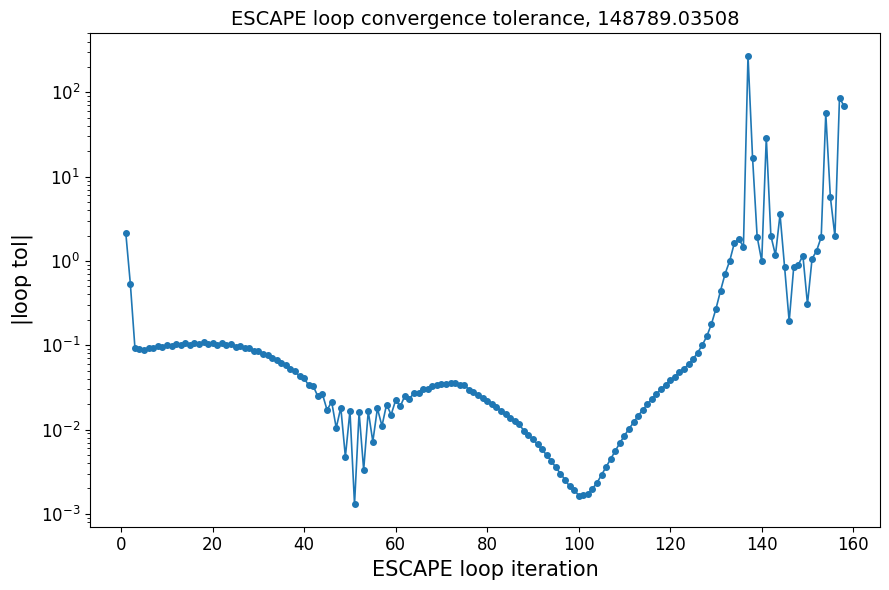

In [10]:
# --- ESCAPE loop convergence tolerance vs iteration ---
# `loop_tol` is the normalized change in pedestal height + width between this
# iteration and the previous one (see profiles_loop_solve_epednn_neped_scan.py);
# the loop stops once abs(loop_tol) < eped_tol_max. It is stored on every dump
# from iteration 1 onward (iteration 0 has nothing prior to compare against).
# Log-scale y-axis since loop_tol spans several orders of magnitude here.

tols = [(i, it['loop_tol']) for i, it in enumerate(iters) if 'loop_tol' in it]
tol_iters, tol_vals = zip(*tols)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(tol_iters, np.abs(tol_vals), 'o-', color='tab:blue', markersize=4, linewidth=1.2)
ax.set_yscale('log')
ax.set_xlabel('ESCAPE loop iteration', fontsize=15)
ax.set_ylabel(r'$|{\rm loop\ tol}|$', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.set_title(f'ESCAPE loop convergence tolerance, {ITER_EQUIL}', fontsize=14)
plt.tight_layout()
plt.show()


[DIIIDSnyder_ESCAPE_nofpscan] successful 302, failed 0, pending 0, outside the solved domain 0
  fixed: C_KBM = 0.3, De_chie_etg = 0.1, alpha_crit = 0.01, nFC_x0 = 2.24e+15, ncx_x0_ratio = 15
  302 equilibria: 302 runs, median ESCAPE/experiment - 1 = +26.9%


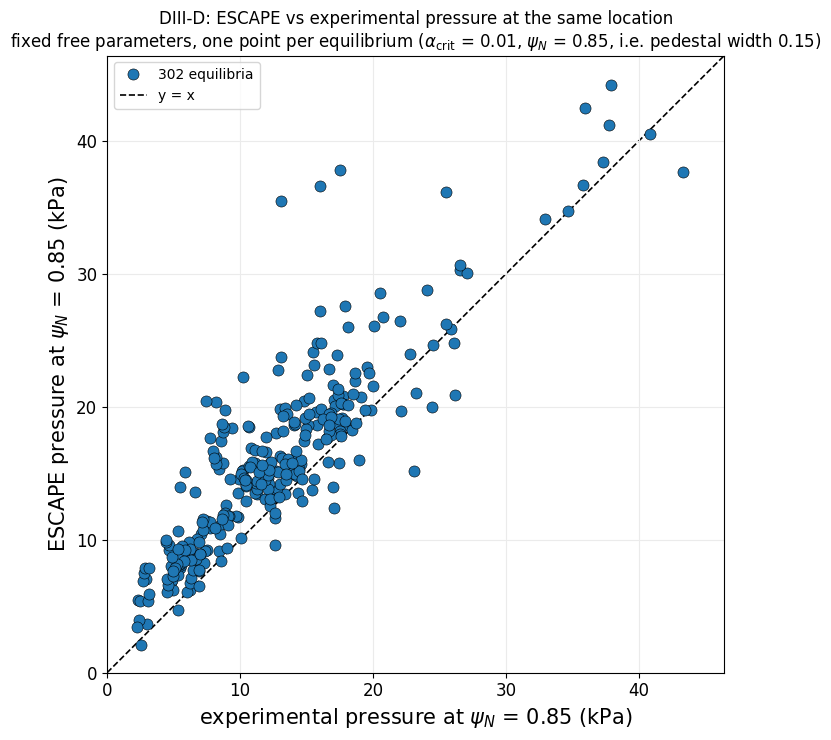

In [11]:
# --- Full scan over all equilibria: ESCAPE vs experimental pressure at psi_N = PSI_EXP ---
# Reads SCAN_DIR/{EQUIL}/neouter{j}_fp{i}/out_dict.npy (failed.npy on failure; a run dir
# with neither is still in flight and is counted as pending). One point per equilibrium
# per scanned free-parameter value, coloured by that value.
# Both axes are the SAME quantity at the SAME radius, so the dashed y = x line means
# agreement:
#   x  experimental  out_dict['profiles']        p = 2*ne*Te ('ne' [m^-3] on 'psi_N_ne',
#                                                'Te' [keV] on 'psi_N_Te')
#   y  ESCAPE        out_dict['profiles_solved'] p = 2*ne*Te ('y' [m^-3] on 'psi_N_ne',
#                                                'T_e' [eV] on 'psi_N')
# The p = 2*ne*Te closure (Ti = Te, ni = ne) is calc_pressure_profile's for these IDA
# files, which carry no main-ion channels. psi_N = 0.85 is the solver's inner boundary
# psi_N_inner, so PSI_EXP < 0.85 has no solved profile to read and those runs are
# reported as "outside the solved domain" and dropped.
# PARAM_KEY = None auto-detects which free parameter the scan varies; a scan that holds
# all of them fixed (as DIIIDSnyder_ESCAPE_nofpscan does) is drawn as a single series.

import re
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# ------------------------------------------------------------------ user input
SCAN_DIR = Path('DIIIDSnyder_ESCAPE_nofpscan')
PSI_EXP = 0.85            # psi_N at which BOTH pressures are read
PARAM_KEY = None          # free parameter on the colour axis; None = auto-detect
# -----------------------------------------------------------------------------

EV_TO_J = 1.602176634e-19
PARAM_COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red',
                'tab:purple', 'tab:brown']
PARAM_LABELS = {
    'De_chie_etg':  r'$D_{e}\chi_{e}^{\mathrm{ETG}}$',
    'C_KBM':        r'$C_{\mathrm{KBM}}$',
    'alpha_crit':   r'$\alpha_{\mathrm{crit}}$',
    'nFC_x0':       r'$n_{\mathrm{FC}}(0)$',
    'ncx_x0_ratio': r'$n_{\mathrm{CX}}(0)/n_{\mathrm{FC}}(0)$',
}


def experimental_p_at(profiles, psi_N):
    """Input-profile thermal pressure [Pa] at psi_N, from a stored `profiles` dict.

    Mirrors calc_pressure_profile for the DIII-D OMFIT IDA layout scan_SCfp_ESCAPE.py
    saves (psi_N_ne / ne [m^-3], psi_N_Te / Te [keV], no Ti or ni): p = 2 * ne * Te.
    """
    psi = np.asarray(profiles['psi_N_ne'], dtype=float)
    ne = np.asarray(profiles['ne'], dtype=float)              # m^-3, on psi_N_ne
    psi_Te = np.asarray(profiles['psi_N_Te'], dtype=float)
    Te_keV = np.asarray(profiles['Te'], dtype=float)          # keV, on psi_N_Te

    # Te onto the ne grid, then p on that grid, and only then interpolate p - the
    # same order calc_pressure_profile uses.
    order = np.argsort(psi_Te)
    Te_keV = np.interp(psi, psi_Te[order], Te_keV[order])
    p = 2.0 * ne * Te_keV * 1e3 * EV_TO_J                     # Pa

    order = np.argsort(psi)
    return float(np.interp(psi_N, psi[order], p[order]))


def escape_p_at(sol, psi_N):
    """Solved-profile ESCAPE thermal pressure [Pa] at psi_N, same p = 2*ne*Te closure.

    NaN if psi_N is outside the solved n_e domain, which starts at psi_N_inner = 0.85.
    """
    psi_ne = np.asarray(sol['psi_N_ne'], dtype=float)
    ne = np.asarray(sol['y'], dtype=float)                    # m^-3
    psi_Te = np.asarray(sol['psi_N'], dtype=float)
    Te_eV = np.asarray(sol['T_e'], dtype=float)               # eV

    if psi_N < psi_ne.min() or psi_N > psi_ne.max():
        return np.nan

    order = np.argsort(psi_Te)
    Te_on_ne = np.interp(psi_ne, psi_Te[order], Te_eV[order])
    p = 2.0 * ne * Te_on_ne * EV_TO_J                         # Pa

    order = np.argsort(psi_ne)
    return float(np.interp(psi_N, psi_ne[order], p[order]))


def load_full_scan(scan_dir, psi_exp=PSI_EXP):
    """Every finished run under scan_dir, with both pressures read at psi_exp."""
    scan_dir = Path(scan_dir)
    runs, failed, pending, outside = [], [], [], []
    for equil_dir in sorted(p for p in scan_dir.iterdir() if p.is_dir()):
        for run_dir in sorted(equil_dir.glob('neouter*_fp*'),
                              key=lambda p: tuple(int(v) for v in
                                                  re.match(r'neouter(\d+)_fp(\d+)$',
                                                           p.name).groups())):
            name = f'{equil_dir.name}/{run_dir.name}'
            out_fp = run_dir / 'out_dict.npy'
            if not out_fp.exists():
                (failed if (run_dir / 'failed.npy').exists() else pending).append(name)
                continue
            d = np.load(out_fp, allow_pickle=True).item()
            p_escape = escape_p_at(d['profiles_solved'], psi_exp)
            if not np.isfinite(p_escape):
                outside.append(name)
                continue
            runs.append({
                'equil':       equil_dir.name,
                'run':         run_dir.name,
                'free_params': {k: float(v) for k, v in d['free_params'].items()},
                'p_escape':    p_escape / 1e3,                          # Pa -> kPa
                'p_exp':       experimental_p_at(d['profiles'], psi_exp) / 1e3,
                'ped_h_eped':  float(d['ESCAPE_ped_h']) * 1e3,          # MPa -> kPa
                'ped_wid':     float(d['ESCAPE_ped_wid']),
            })
    return runs, failed, pending, outside


runs, failed, pending, outside = load_full_scan(SCAN_DIR)
print(f'[{SCAN_DIR}] successful {len(runs)}, failed {len(failed)}, '
      f'pending {len(pending)}, outside the solved domain {len(outside)}')
if not runs:
    raise SystemExit('no usable runs, nothing to plot')

# Which free parameter actually varies across the scan.
all_keys = sorted(runs[0]['free_params'])
varying = [k for k in all_keys if len({r['free_params'][k] for r in runs}) > 1]
param_key = PARAM_KEY if PARAM_KEY is not None else (varying[0] if varying else None)
if len(varying) > 1:
    print(f'  more than one free parameter varies ({", ".join(varying)}); '
          f'colouring by {param_key} only')
fixed = {k: runs[0]['free_params'][k] for k in all_keys
         if k != param_key and len({r['free_params'][k] for r in runs}) == 1}
print('  fixed: ' + ', '.join(f'{k} = {v:g}' for k, v in fixed.items()))

param_vals = sorted({r['free_params'][param_key] for r in runs}) if param_key else [None]
param_label = PARAM_LABELS.get(param_key, param_key)
param_color = {v: PARAM_COLORS[k % len(PARAM_COLORS)] for k, v in enumerate(param_vals)}

fig, ax = plt.subplots(figsize=(8, 7.5))
for v in param_vals:
    g = runs if v is None else [r for r in runs
                                if np.isclose(r['free_params'][param_key], v)]
    if not g:
        continue
    p_escape = np.array([r['p_escape'] for r in g])
    p_exp = np.array([r['p_exp'] for r in g])
    label = (f'{len(g)} equilibria' if v is None
             else rf'{param_label} = {v:g}')
    ax.plot(p_exp, p_escape, 'o', color=param_color[v], markersize=8, linestyle='none',
            markeredgecolor='black', markeredgewidth=0.4, label=label)
    rel = np.median(p_escape / p_exp - 1.0) * 100
    print(f'  {label}: {len(g)} runs, median ESCAPE/experiment - 1 = {rel:+.1f}%')

# y = x: at this psi_N both axes are the same quantity, so this is agreement.
lim_hi = 1.05 * max(max(r['p_escape'] for r in runs), max(r['p_exp'] for r in runs))
ax.plot([0, lim_hi], [0, lim_hi], 'k--', linewidth=1.2, zorder=0, label='y = x')

ax.set_xlim(0, lim_hi)
ax.set_ylim(0, lim_hi)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(rf'experimental pressure at $\psi_N$ = {PSI_EXP:g} (kPa)', fontsize=15)
ax.set_ylabel(rf'ESCAPE pressure at $\psi_N$ = {PSI_EXP:g} (kPa)', fontsize=15)
ax.tick_params(axis='both', labelsize=12)
ax.grid(color='0.92', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(fontsize=10, loc='best')
scan_title = (f'{param_label} scan' if param_key else 'fixed free parameters')
alpha_note = (rf'$\alpha_{{\mathrm{{crit}}}}$ = {fixed["alpha_crit"]:g}, '
              if 'alpha_crit' in fixed else '')
ax.set_title('DIII-D: ESCAPE vs experimental pressure at the same location\n'
             f'{scan_title}, one point per equilibrium ('
             + alpha_note
             + rf'$\psi_N$ = {PSI_EXP:g}, i.e. pedestal width {1 - PSI_EXP:g})',
             fontsize=12)
plt.tight_layout()
plt.show()
